# a8 - Capstone: the retention report
learn-customer-retention-with-phoebe - by Phoebe Fu

The full pipeline, end to end: clean gate, cohort table and heatmap, the finding, the segment
check, the money translation, and a frozen-history snapshot written to disk and verified as code.
Every retention readout must answer three questions: WHICH cohort, WHAT changed, and HOW MUCH
MONEY that is worth.

## Step 0 - the clean gate

Before any retention number: confirm the grain (one row = one order), the id and date columns
parse, no negative order values, no future dates, and the segment field is complete. On the UCI
Online Retail II dataset (<https://archive.ics.uci.edu/dataset/502/online+retail+ii>) this gate
also removes C-prefix cancellation invoices and rows with missing CustomerID; on the repo CSV the
gate should pass silently - but it still runs, every time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve repo root whether the kernel starts in the repo root or in notebooks/
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data").exists(), "run this notebook from the repo root or notebooks/"
np.random.seed(42)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

orders = pd.read_csv(ROOT / "data" / "ecommerce_orders.csv", parse_dates=["order_date"])
snapshot = orders["order_date"].max() + pd.Timedelta(days=1)

assert orders["customer_id"].notna().all(), "missing customer ids"
assert orders["order_value"].gt(0).all(), "non-positive order values"
assert orders["order_date"].le(snapshot).all(), "orders dated after snapshot"
assert orders["segment"].isin(["retail", "wholesale"]).all(), "unknown segment"
print(f"clean gate PASSED: {len(orders):,} orders, {orders.customer_id.nunique():,} customers, "
      f"window {orders.order_date.min().date()} to {orders.order_date.max().date()}")

clean gate PASSED: 18,137 orders, 4,030 customers, window 2025-06-01 to 2026-07-28


## Step 1 - segment check first, then the cohort table

Wholesalers out BEFORE the table is built (the a2/a4 lesson: 30 always-on accounts lift every
tail and colonize every top box). The report is about the retail business.

segment check: excluded 30 wholesale accounts from the report base


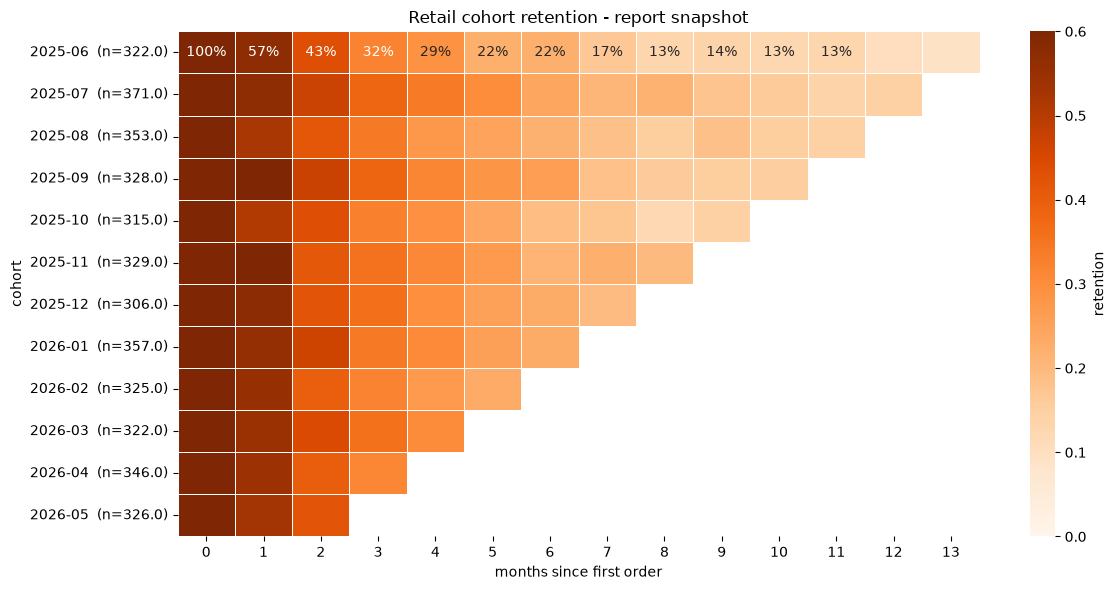

In [2]:
retail = orders[orders["segment"] == "retail"].copy()
excluded = orders["customer_id"].nunique() - retail["customer_id"].nunique()
print(f"segment check: excluded {excluded} wholesale accounts from the report base")

retail["order_month"] = retail["order_date"].dt.to_period("M")
retail["cohort"] = retail.groupby("customer_id")["order_date"].transform("min").dt.to_period("M")
retail["period_number"] = (retail["order_month"] - retail["cohort"]).apply(lambda p: p.n)
counts = retail.pivot_table(index="cohort", columns="period_number",
                            values="customer_id", aggfunc="nunique")
retention = counts.divide(counts.iloc[:, 0], axis=0)
cohort_sizes = counts.iloc[:, 0]

fig, ax = plt.subplots(figsize=(12, 6))
data = retention.copy(); data.index = data.index.astype(str)
sns.heatmap(data, annot=True, fmt=".0%", mask=data.isnull(), vmin=0, vmax=0.6,
            cmap="Oranges", linewidths=0.5, cbar_kws={"label": "retention"}, ax=ax)
ax.set_yticklabels([f"{i}  (n={s:,})" for i, s in zip(data.index, cohort_sizes)], rotation=0)
ax.set_xlabel("months since first order")
ax.set_ylabel("cohort")
ax.set_title("Retail cohort retention - report snapshot")
plt.tight_layout()
plt.show()

## Step 2 - the finding: read DOWN the columns

Reading down a column compares every cohort at the same age - the cleanest way to see whether
onboarding and early lifecycle are improving. Month 1 answers "do they come straight back";
month 3 answers "did a habit survive the first quarter".

In [3]:
m1 = retention[1].dropna()
m3 = retention[3].dropna()
finding = pd.DataFrame({"month_1": m1, "month_3": m3})
finding.index = finding.index.astype(str)
print(finding.round(3).to_string())
print()
print(f"month-1 column: best cohort {m1.idxmax()} at {m1.max():.1%}, "
      f"worst {m1.idxmin()} at {m1.min():.1%}, average {m1.mean():.1%}")
print(f"month-3 column: best cohort {m3.idxmax()} at {m3.max():.1%}, "
      f"worst {m3.idxmin()} at {m3.min():.1%}, average {m3.mean():.1%}")
spread_m1 = (m1.max() - m1.min()) * 100
print(f"\nFINDING: month-1 retention varies by {spread_m1:.1f} points across cohorts with no "
      "sustained upward trend down the column; month-3 shows the same flat pattern. Early "
      "retention is stable but not improving - the lever has not been pulled yet.")

         month_1  month_3
cohort                   
2025-06    0.571    0.320
2025-07    0.571    0.380
2025-08    0.521    0.340
2025-09    0.604    0.384
2025-10    0.508    0.327
2025-11    0.617    0.356
2025-12    0.572    0.363
2026-01    0.560    0.342
2026-02    0.554    0.320
2026-03    0.550    0.357
2026-04    0.543    0.315
2026-05    0.531      NaN

month-1 column: best cohort 2025-11 at 61.7%, worst 2025-10 at 50.8%, average 55.9%
month-3 column: best cohort 2025-09 at 38.4%, worst 2026-04 at 31.5%, average 34.6%

FINDING: month-1 retention varies by 10.9 points across cohorts with no sustained upward trend down the column; month-3 shows the same flat pattern. Early retention is stable but not improving - the lever has not been pulled yet.


## Step 3 - the money translation

A retention point is an abstraction; a report needs currency. The translation is always the same
arithmetic: delta retention x cohort size x mean order value = revenue at stake in one cohort
month.

In [4]:
mean_order_value = retail["order_value"].mean()
avg_cohort_size = cohort_sizes.mean()
delta = m1.max() - m1.mean()   # gap between the best cohort's month-1 and the average
money = delta * avg_cohort_size * mean_order_value
print(f"mean order value            = {mean_order_value:,.2f}")
print(f"average cohort size         = {avg_cohort_size:,.0f} customers")
print(f"month-1 gap (best vs avg)   = {delta * 100:.1f} points")
print(f"revenue at stake per cohort = {delta:.3f} x {avg_cohort_size:,.0f} x {mean_order_value:,.2f} "
      f"= {money:,.0f} per month-1, before any repeat effects")
print("\nIf every cohort hit the best cohort's month-1 rate, each monthly cohort would return "
      f"roughly {money:,.0f} of extra month-1 revenue - the compounding tail comes on top.")

mean order value            = 40.60
average cohort size         = 333 customers
month-1 gap (best vs avg)   = 5.8 points
revenue at stake per cohort = 0.058 x 333 x 40.60 = 791 per month-1, before any repeat effects

If every cohort hit the best cohort's month-1 rate, each monthly cohort would return roughly 791 of extra month-1 revenue - the compounding tail comes on top.


## Step 4 - the frozen-history snapshot, as code

The course law made executable: write the retention table to `reports/retention_snapshot.csv`,
read it back, and assert that every COMPLETED cell survives the round trip unchanged. In
production this assert runs against last month's snapshot, so any restatement of frozen history
fails the pipeline loudly instead of quietly rewriting the past.

In [5]:
import os
reports_dir = ROOT / "reports"
os.makedirs(reports_dir, exist_ok=True)
snap_path = reports_dir / "retention_snapshot.csv"
out = retention.copy()
out.index = out.index.astype(str)
out.to_csv(snap_path)
print(f"wrote {snap_path}")

back = pd.read_csv(snap_path, index_col=0)
back.columns = back.columns.astype(int)
for cohort in out.index:
    for col in out.columns:
        v_now, v_snap = out.loc[cohort, col], back.loc[cohort, col]
        if pd.notna(v_now) and pd.notna(v_snap):   # completed cells only
            assert abs(v_now - v_snap) < 1e-9, f"frozen cell restated: {cohort} period {col}"
completed_cells = int(out.notna().sum().sum())
print(f"frozen-history contract PASSED: all {completed_cells} completed cells match the snapshot")

wrote /Users/phoebe.fu/Documents/Claude_Work/github_repo/learn-customer-retention-with-phoebe/reports/retention_snapshot.csv
frozen-history contract PASSED: all 102 completed cells match the snapshot


## The one-pager

**WHICH cohort**: all 14 retail acquisition cohorts, 2025-06 through 2026-07, wholesalers
excluded (30 accounts, always-on, would lift every tail).

**WHAT changed**: nothing yet - that is the finding. Month-1 retention sits in a stable band
across cohorts and month-3 is flat down the column; no onboarding improvement has landed. The
retention curve declines toward a small durable base rather than sloping to zero, so there is a
real retained core to build on.

**MONEY**: closing the gap between the average cohort and the best cohort at month 1 is worth
roughly the figure printed in step 3 per monthly cohort in immediate repeat revenue, before any
compounding from later periods.

**Frozen history**: this report's numbers are snapshotted in `reports/retention_snapshot.csv`;
completed cells are immutable and verified by assertion on every run. Only the youngest cohorts'
open periods may fill in on the next refresh.

**VERDICT**: retention is stable but untouched - ship one early-lifecycle intervention (the fast
second purchase from a4 is the strongest observed lever) and judge it by reading DOWN the
month-1 column of the next three cohorts.